In [21]:
from __future__ import print_function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error,accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [22]:
df = pd.read_csv("yellow-tripdata.csv")
df.head()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             41202 non-null  int64  
 1   VendorID               41202 non-null  int64  
 2   passenger_count        41202 non-null  int64  
 3   trip_distance          41202 non-null  float64
 4   RatecodeID             41202 non-null  int64  
 5   store_and_fwd_flag     41202 non-null  int64  
 6   PULocationID           41202 non-null  int64  
 7   DOLocationID           41202 non-null  int64  
 8   payment_type           41202 non-null  int64  
 9   fare_amount            41202 non-null  float64
 10  mta_tax                41202 non-null  float64
 11  tolls_amount           41202 non-null  float64
 12  improvement_surcharge  41202 non-null  int64  
 13  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(9)
memory usage: 4.4 MB


<Axes: >

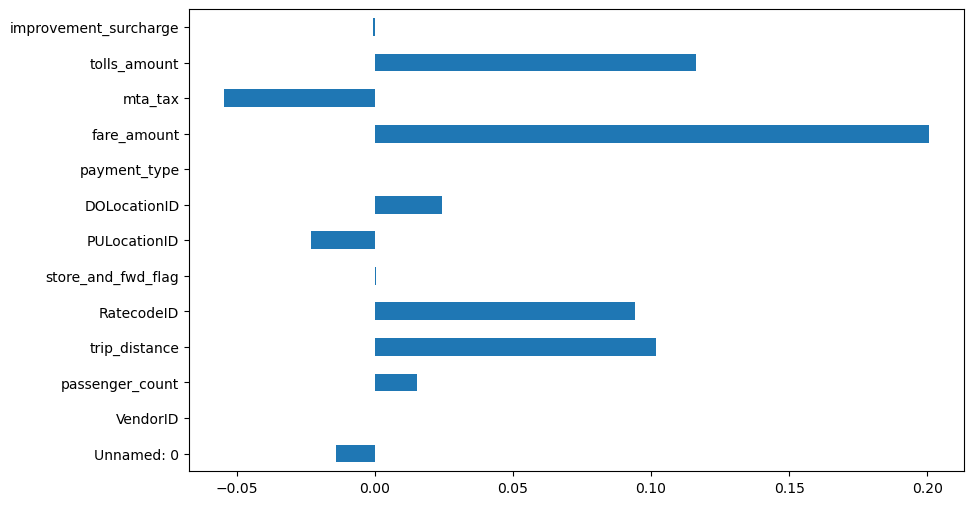

In [23]:
correlation_values = df.corr()['tip_amount'].drop('tip_amount')
correlation_values.plot(kind='barh', figsize=(10, 6))

In [24]:
y = df[['tip_amount']].values.astype('float32')
proc_data = df.drop(['tip_amount'], axis=1)
X = proc_data.values
X = normalize(X, axis=1, norm='l1', copy=False)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [26]:
from sklearn.tree import DecisionTreeRegressor

dt_reg = DecisionTreeRegressor(criterion = 'squared_error',
                               max_depth=8, 
                               random_state=35)

In [27]:
dt_reg.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,35
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [28]:
y_pred = dt_reg.predict(X_test)

mse_score = mean_squared_error(y_test, y_pred)
print('MSE score : {0:.3f}'.format(mse_score))

r2_score = dt_reg.score(X_test,y_test)
print('R^2 score : {0:.3f}'.format(r2_score))

MSE score : 25.317
R^2 score : -0.002
